In [19]:
import pandas as  pd

df_train = pd.read_parquet("C:/Users/jesus/Escritorio/Uni/PD2/PD2/data/Train/train_final.parquet")
df_test = pd.read_parquet("C:/Users/jesus/Escritorio/Uni/PD2/PD2/data/Train/test_final.parquet")

df_meteo = pd.read_csv("C:/Users/jesus/Escritorio/Uni/PD2/PD2/data/datos_meteorologicos.csv", delimiter=",")

In [20]:
df_train.dtypes

ICAO                       object
llegada_punto      datetime64[ns]
salida_punto       datetime64[ns]
despegue           datetime64[ns]
tiempo_espera             float64
aircraft_type              object
llegada_lon               float64
llegada_lat               float64
salida_lon                float64
salida_lat                float64
holding_point              object
parado                       bool
runway                     object
fecha_despegue             object
hora_despegue               int64
timestamp          datetime64[ns]
tiempo_esperado           float64
runway_occupied           float64
queue_length              float64
time_since_free           float64
dtype: object

In [22]:
df_test.dtypes

ICAO                       object
llegada_punto      datetime64[ns]
salida_punto       datetime64[ns]
despegue           datetime64[ns]
tiempo_espera             float64
aircraft_type              object
llegada_lon               float64
llegada_lat               float64
salida_lon                float64
salida_lat                float64
holding_point              object
parado                       bool
runway                     object
fecha_despegue             object
hora_despegue               int64
timestamp          datetime64[ns]
tiempo_esperado           float64
runway_occupied           float64
queue_length              float64
time_since_free           float64
dtype: object

In [23]:
for df in (df_train, df_test):
    df["llegada_punto"]  = pd.to_datetime(df["llegada_punto"])
    df["salida_punto"]   = pd.to_datetime(df["salida_punto"])
    df["despegue"]       = pd.to_datetime(df["despegue"])
    df["timestamp"]      = pd.to_datetime(df["timestamp"])
    df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"])

In [25]:
print(df_train.dtypes)
print(df_test.dtypes)

ICAO                       object
llegada_punto      datetime64[ns]
salida_punto       datetime64[ns]
despegue           datetime64[ns]
tiempo_espera             float64
aircraft_type              object
llegada_lon               float64
llegada_lat               float64
salida_lon                float64
salida_lat                float64
holding_point              object
parado                       bool
runway                     object
fecha_despegue     datetime64[ns]
hora_despegue               int64
timestamp          datetime64[ns]
tiempo_esperado           float64
runway_occupied           float64
queue_length              float64
time_since_free           float64
dtype: object
ICAO                       object
llegada_punto      datetime64[ns]
salida_punto       datetime64[ns]
despegue           datetime64[ns]
tiempo_espera             float64
aircraft_type              object
llegada_lon               float64
llegada_lat               float64
salida_lon                float64


In [26]:
df_parado_train = df_train[df_train["parado"]].copy()
df_parado_test = df_test[df_test["parado"]].copy()

In [27]:
df_parado_train

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue,timestamp,tiempo_esperado,runway_occupied,queue_length,time_since_free
1,34448d,2024-12-28 23:28:18.845,2024-12-28 23:30:59.989,2024-12-28 23:33:42.908,204.063,Medium 2 (between 34000 kg to 136000 kg),-3.576299,40.492498,-3.575753,40.492661,Z4,True,18R/36L,2024-12-28,23,2024-12-28 23:30:18.845,120.0,1.0,2.0,42.782
2,3445d4,2025-01-18 14:50:34.790,2025-01-18 14:53:09.865,2025-01-18 14:55:28.387,158.597,Medium 2 (between 34000 kg to 136000 kg),-3.576315,40.492568,-3.575729,40.492722,Z4,True,18R/36L,2025-01-18,14,2025-01-18 14:52:49.790,135.0,1.0,1.0,83.390
3,484349,2024-12-13 16:15:58.335,2024-12-13 16:23:21.703,2024-12-13 16:25:46.776,198.441,Medium 2 (between 34000 kg to 136000 kg),-3.576097,40.491823,-3.575623,40.491978,Z2,True,18R/36L,2024-12-13,16,2024-12-13 16:22:28.335,390.0,1.0,1.0,68.339
4,343385,2025-01-16 19:05:24.045,2025-01-16 19:06:42.286,2025-01-16 19:07:25.427,51.382,Medium 2 (between 34000 kg to 136000 kg),-3.576299,40.492568,-3.575816,40.492719,Z4,True,18R/36L,2025-01-16,19,2025-01-16 19:06:34.045,70.0,0.0,0.0,144.022
6,e94c88,2024-12-11 14:25:39.352,2024-12-11 14:30:06.733,2024-12-11 14:31:12.466,108.114,Heavy (larger than 136000 kg),-3.572913,40.491881,-3.573517,40.491840,Z3,True,18R/36L,2024-12-11,14,2024-12-11 14:29:24.352,225.0,1.0,1.0,50.347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258843,344503,2025-01-17 14:32:04.464,2025-01-17 14:34:57.379,2025-01-17 14:36:16.442,251.978,Heavy (larger than 136000 kg),-3.572906,40.491852,-3.573486,40.491852,Z3,True,18R/36L,2025-01-17,14,2025-01-17 14:32:04.464,0.0,1.0,1.0,67.702
258844,49d2b9,2025-01-09 10:18:07.152,2025-01-09 10:19:54.993,2025-01-09 10:20:47.938,160.786,Medium 2 (between 34000 kg to 136000 kg),-3.559555,40.494461,-3.558977,40.494802,K2,True,14L/32R,2025-01-09,10,2025-01-09 10:18:07.152,0.0,0.0,0.0,346.152
258845,344416,2024-11-07 22:32:01.273,2024-11-07 22:32:58.101,2024-11-07 22:34:27.373,141.100,Medium 2 (between 34000 kg to 136000 kg),-3.560944,40.499434,-3.560349,40.499508,Y1,True,18L/36R,2024-11-07,22,2024-11-07 22:32:06.273,5.0,1.0,1.0,3.179
258846,3472c9,2025-01-11 15:24:58.788,2025-01-11 15:31:22.325,2025-01-11 15:32:34.489,380.701,Medium 2 (between 34000 kg to 136000 kg),-3.576309,40.492538,-3.575706,40.492673,Z4,True,18R/36L,2025-01-11,15,2025-01-11 15:26:13.788,75.0,0.0,0.0,118.229


In [28]:
# ===== 2) Limpiar y convertir tipos en df_meteo =====
cols_numericas = [
    "Precipitación", "Temperatura", "Humedad", "Viento", "Viento máximo",
    "Temperatura mínima", "Temperatura máxima"
]

# Reemplazar comas por puntos y convertir a float
for col in cols_numericas:
    df_meteo[col] = df_meteo[col].str.replace(",", ".").astype(float)

# Convertir 'Fecha' a datetime.date y 'Hora' a entero
df_meteo["Fecha"] = pd.to_datetime(df_meteo["Fecha"]).dt.date
df_meteo["Hora"]  = pd.to_datetime(df_meteo["Hora"], format="%H:%M").dt.hour


In [29]:
df_parado_train = df_train[df_train["parado"]].copy()
df_parado_test  = df_test[df_test["parado"]].copy()

# Extraer Fecha y Hora desde timestamp
for df_ in (df_parado_train, df_parado_test):
    df_["Fecha"] = df_["timestamp"].dt.date
    df_["Hora"]  = df_["timestamp"].dt.hour

# Merge con datos meteorológicos por Fecha y Hora
df_train_merged = df_parado_train.merge(df_meteo, how="left", on=["Fecha", "Hora"])
df_test_merged  = df_parado_test.merge(df_meteo,  how="left", on=["Fecha", "Hora"])

In [30]:
df_train_merged

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,...,Hora,Precipitación,Temperatura,Humedad,Viento,Dirección,Viento máximo,Dirección viento máximo,Temperatura mínima,Temperatura máxima
0,34448d,2024-12-28 23:28:18.845,2024-12-28 23:30:59.989,2024-12-28 23:33:42.908,204.063,Medium 2 (between 34000 kg to 136000 kg),-3.576299,40.492498,-3.575753,40.492661,...,23,0.0,1.9,92.0,2.1,Norte 350°,3.6,Norte 360°,1.8,2.4
1,3445d4,2025-01-18 14:50:34.790,2025-01-18 14:53:09.865,2025-01-18 14:55:28.387,158.597,Medium 2 (between 34000 kg to 136000 kg),-3.576315,40.492568,-3.575729,40.492722,...,14,0.0,9.2,53.0,0.4,Suroeste 230°,3.1,Oeste 280°,7.7,9.7
2,484349,2024-12-13 16:15:58.335,2024-12-13 16:23:21.703,2024-12-13 16:25:46.776,198.441,Medium 2 (between 34000 kg to 136000 kg),-3.576097,40.491823,-3.575623,40.491978,...,16,0.0,8.9,77.0,0.9,Noreste 40°,2.1,Norte 360°,8.9,9.2
3,343385,2025-01-16 19:05:24.045,2025-01-16 19:06:42.286,2025-01-16 19:07:25.427,51.382,Medium 2 (between 34000 kg to 136000 kg),-3.576299,40.492568,-3.575816,40.492719,...,19,0.0,7.4,52.0,1.4,Este 80°,3.1,Este 80°,7.3,9.7
4,e94c88,2024-12-11 14:25:39.352,2024-12-11 14:30:06.733,2024-12-11 14:31:12.466,108.114,Heavy (larger than 136000 kg),-3.572913,40.491881,-3.573517,40.491840,...,14,0.0,8.1,54.0,2.8,Norte 350°,6.2,Norte 340°,8.0,8.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171010,344503,2025-01-17 14:32:04.464,2025-01-17 14:34:57.379,2025-01-17 14:36:16.442,251.978,Heavy (larger than 136000 kg),-3.572906,40.491852,-3.573486,40.491852,...,14,0.0,11.2,45.0,3.0,Noreste 40°,6.7,Noreste 50°,9.8,11.2
171011,49d2b9,2025-01-09 10:18:07.152,2025-01-09 10:19:54.993,2025-01-09 10:20:47.938,160.786,Medium 2 (between 34000 kg to 136000 kg),-3.559555,40.494461,-3.558977,40.494802,...,10,0.0,10.4,89.0,5.9,Suroeste 210°,12.4,Suroeste 220°,9.5,10.5
171012,344416,2024-11-07 22:32:01.273,2024-11-07 22:32:58.101,2024-11-07 22:34:27.373,141.100,Medium 2 (between 34000 kg to 136000 kg),-3.560944,40.499434,-3.560349,40.499508,...,22,0.0,12.6,90.0,0.0,NaN,1.0,Sureste 130°,12.4,13.8
171013,3472c9,2025-01-11 15:24:58.788,2025-01-11 15:31:22.325,2025-01-11 15:32:34.489,380.701,Medium 2 (between 34000 kg to 136000 kg),-3.576309,40.492538,-3.575706,40.492673,...,15,0.0,18.8,54.0,1.3,Norte 360°,4.6,Sur 180°,18.0,19.1


In [31]:
# Para TRAIN
df_train_filtrado = df_train_merged[df_train_merged["tiempo_espera"] <= 500].copy()
print(f"TRAIN - antes de filtrar: {len(df_train_merged)} registros")
print(f"TRAIN - después de filtrar: {len(df_train_filtrado)} registros\n")

# Para TEST
df_test_filtrado = df_test_merged[df_test_merged["tiempo_espera"] <= 500].copy()
print(f"TEST  - antes de filtrar: {len(df_test_merged)} registros")
print(f"TEST  - después de filtrar: {len(df_test_filtrado)} registros")


TRAIN - antes de filtrar: 171015 registros
TRAIN - después de filtrar: 165447 registros

TEST  - antes de filtrar: 42626 registros
TEST  - después de filtrar: 41248 registros


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.notebook import tqdm

# Preparamos los datos para el modelo

# Para train
df_train_model = df_train_filtrado.drop(columns=[
    "ICAO", "llegada_punto", "salida_punto", "salida_lon", "salida_lat",
    "despegue", "runway", "fecha_despegue", "hora_despegue",
    "timestamp", "holding_point"
])

# Para test
df_test_model = df_test_filtrado.drop(columns=[
    "ICAO", "llegada_punto", "salida_punto", "salida_lon", "salida_lat",
    "despegue", "runway", "fecha_despegue", "hora_despegue",
    "timestamp", "holding_point"
])

In [33]:
X_train = df_train_model.drop(columns="tiempo_espera")
y_train = df_train_model["tiempo_espera"]

X_test  = df_test_model.drop(columns="tiempo_espera")
y_test  = df_test_model["tiempo_espera"]

In [12]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

# Ajustamos el preprocesador a todo X
preprocessor.fit(X)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['llegada_lon', 'llegada_lat',
                                  'tiempo_esperado', 'Precipitación',
                                  'Temperatura', 'Humedad', 'Viento',
                                  'Viento máximo', 'Temperatura mínima',
                                  'Temperatura máxima']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['aircraft_type', 'parado', 'Fecha',
                                  'Dirección', 'Dirección viento máximo'])])

In [35]:
# Obtener nombres de las características categóricas tras OneHotEncoder
cat_feats = preprocessor.named_transformers_["cat"] \
    .get_feature_names_out(cat_cols).tolist()

# Lista completa de features que entran al modelo
all_feats = num_cols + cat_feats + ["otros_clusters_ocupados", "tiempo_esperado"]

print("Features que entran al modelo:")
for f in all_feats:
    print(" ", f)


Features que entran al modelo:
  llegada_lon
  llegada_lat
  tiempo_esperado
  Precipitación
  Temperatura
  Humedad
  Viento
  Viento máximo
  Temperatura mínima
  Temperatura máxima
  aircraft_type_Heavy (larger than 136000 kg)
  aircraft_type_High vortex aircraft
  aircraft_type_Light (less than 7000 kg)
  aircraft_type_Medium 1 (between 7000 kg and 34000 kg)
  aircraft_type_Medium 2 (between 34000 kg to 136000 kg)
  aircraft_type_None
  parado_True
  Fecha_2024-11-07
  Fecha_2024-11-08
  Fecha_2024-11-09
  Fecha_2024-11-10
  Fecha_2024-11-11
  Fecha_2024-11-12
  Fecha_2024-11-13
  Fecha_2024-11-14
  Fecha_2024-11-15
  Fecha_2024-11-16
  Fecha_2024-11-17
  Fecha_2024-11-18
  Fecha_2024-11-19
  Fecha_2024-11-20
  Fecha_2024-11-21
  Fecha_2024-11-22
  Fecha_2024-11-23
  Fecha_2024-11-24
  Fecha_2024-11-25
  Fecha_2024-11-26
  Fecha_2024-11-27
  Fecha_2024-11-28
  Fecha_2024-11-30
  Fecha_2024-12-01
  Fecha_2024-12-02
  Fecha_2024-12-03
  Fecha_2024-12-04
  Fecha_2024-12-05
  Fecha_202

In [36]:
# Re-definir el preprocesador con las columnas numéricas y categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])


In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
# 1) Transformar con el preprocesador ya definido
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# 2) Configurar el RandomForest con warm_start para ir añadiendo árboles
from sklearn.ensemble import RandomForestRegressor
from tqdm.notebook import tqdm
n_estimators = 100
rf = RandomForestRegressor(n_estimators=1, warm_start=True, random_state=42)

# 3) Entrenar añadiendo un árbol cada iteración
for i in tqdm(range(1, n_estimators + 1), desc="Entrenando RF"):
    rf.n_estimators = i
    rf.fit(X_train_t, y_train)

# 4) Predecir sobre el set de test
y_pred = rf.predict(X_test_t)


Entrenando RF:   0%|          | 0/100 [00:00<?, ?it/s]

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")


MAE:  8.91
RMSE: 21.66
R²:   0.942


In [41]:
# Celda: Obtener nombres de las features tras el preprocesado
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

# Nombres generados por el OneHotEncoder
cat_features = preprocessor.named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

# Lista completa de nombres de features
feature_names = num_cols + cat_features.tolist()

print(f"Total de features: {len(feature_names)}")


Total de features: 175


In [42]:
import numpy as np

# Importancias crudas del modelo
importances = rf.feature_importances_

# Índices ordenados de mayor a menor
indices = np.argsort(importances)[::-1]

# Miramos los 10 primeros
top_n = 10
top_idx = indices[:top_n]

for rank, idx in enumerate(top_idx, start=1):
    print(f"{rank:2d}. {feature_names[idx]:40s} → {importances[idx]:.4f}")


 1. llegada_lat                              → 0.1893
 2. tiempo_esperado                          → 0.1860
 3. llegada_lon                              → 0.1110
 4. Humedad                                  → 0.0482
 5. Viento                                   → 0.0446
 6. Temperatura mínima                       → 0.0418
 7. Temperatura                              → 0.0358
 8. Viento máximo                            → 0.0323
 9. Temperatura máxima                       → 0.0310
10. aircraft_type_Medium 2 (between 34000 kg to 136000 kg) → 0.0148


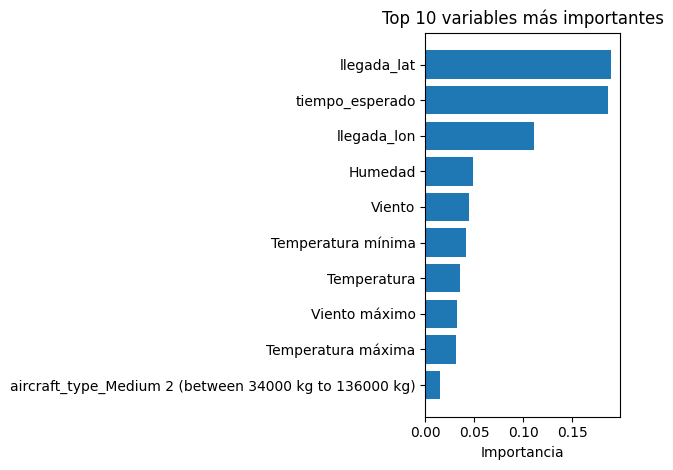

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.barh(range(top_n)[::-1], importances[top_idx])
plt.yticks(range(top_n)[::-1], np.array(feature_names)[top_idx])
plt.xlabel("Importancia")
plt.title(f"Top {top_n} variables más importantes")
plt.tight_layout()
plt.show()


## DEFINITIVO

In [46]:
df = pd.read_parquet("C:/Users/jesus/Escritorio/Uni/PD2/PD2/data/Train/train_final.parquet")

df_meteo = pd.read_csv("C:/Users/jesus/Escritorio/Uni/PD2/PD2/data/datos_meteorologicos.csv", delimiter=",")

In [48]:
df["llegada_punto"]  = pd.to_datetime(df["llegada_punto"])
df["salida_punto"]   = pd.to_datetime(df["salida_punto"])
df["despegue"]       = pd.to_datetime(df["despegue"])
df["timestamp"]      = pd.to_datetime(df["timestamp"])
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"])

In [49]:
df_parado = df[df["parado"]].copy()

In [50]:
# Convertir comas a puntos y strings a float donde sea necesario
cols_numericas = [
    "Precipitación", "Temperatura", "Humedad", "Viento", "Viento máximo",
    "Temperatura mínima", "Temperatura máxima"
]
for col in cols_numericas:
    df_meteo[col] = df_meteo[col].str.replace(",", ".").astype(float)

# Convertir 'Fecha' a datetime.date y 'Hora' a número
df_meteo["Fecha"] = pd.to_datetime(df_meteo["Fecha"]).dt.date
df_meteo["Hora"] = pd.to_datetime(df_meteo["Hora"], format="%H:%M").dt.hour

In [51]:
# Creamos las columnas necesarias en df_parado
df_parado["Fecha"] = df_parado["timestamp"].dt.date
df_parado["Hora"] = df_parado["timestamp"].dt.hour

# Hacemos el merge
df_merged = df_parado.merge(df_meteo, how="left", on=["Fecha", "Hora"])

In [52]:
df_filtrado = df_merged[df_merged["tiempo_espera"] <= 500].copy()

print(f"Registros antes de filtrar: {len(df_merged)}")
print(f"Registros después de filtrar: {len(df_filtrado)}")

Registros antes de filtrar: 171015
Registros después de filtrar: 165447


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.notebook import tqdm

df_modelo = df_filtrado.drop(columns=[
    "ICAO", "llegada_punto", "salida_punto", "salida_lon", "salida_lat","despegue",
    "runway", "fecha_despegue", "hora_despegue", "timestamp",
    "holding_point" 
])

In [54]:
X = df_modelo.drop(columns=["tiempo_espera"])
y = df_modelo["tiempo_espera"]

In [55]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object","bool"]).columns.tolist()

In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

preprocessor.fit(X)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['llegada_lon', 'llegada_lat',
                                  'tiempo_esperado', 'runway_occupied',
                                  'queue_length', 'time_since_free',
                                  'Precipitación', 'Temperatura', 'Humedad',
                                  'Viento', 'Viento máximo',
                                  'Temperatura mínima', 'Temperatura máxima']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['aircraft_type', 'parado', 'Fecha',
                                  'Dirección', 'Dirección viento máximo'])])

In [57]:
cat_feats = preprocessor.named_transformers_["cat"]\
    .get_feature_names_out(cat_cols).tolist()
all_feats = num_cols + cat_feats + ["otros_cluster_ocupados", "tiempo_esperado"]
print("Features que entran al modelo:")
for f in all_feats:
    print(" ",f)

Features que entran al modelo:
  llegada_lon
  llegada_lat
  tiempo_esperado
  runway_occupied
  queue_length
  time_since_free
  Precipitación
  Temperatura
  Humedad
  Viento
  Viento máximo
  Temperatura mínima
  Temperatura máxima
  aircraft_type_Heavy (larger than 136000 kg)
  aircraft_type_High vortex aircraft
  aircraft_type_Light (less than 7000 kg)
  aircraft_type_Medium 1 (between 7000 kg and 34000 kg)
  aircraft_type_Medium 2 (between 34000 kg to 136000 kg)
  aircraft_type_None
  parado_True
  Fecha_2024-11-07
  Fecha_2024-11-08
  Fecha_2024-11-09
  Fecha_2024-11-10
  Fecha_2024-11-11
  Fecha_2024-11-12
  Fecha_2024-11-13
  Fecha_2024-11-14
  Fecha_2024-11-15
  Fecha_2024-11-16
  Fecha_2024-11-17
  Fecha_2024-11-18
  Fecha_2024-11-19
  Fecha_2024-11-20
  Fecha_2024-11-21
  Fecha_2024-11-22
  Fecha_2024-11-23
  Fecha_2024-11-24
  Fecha_2024-11-25
  Fecha_2024-11-26
  Fecha_2024-11-27
  Fecha_2024-11-28
  Fecha_2024-11-30
  Fecha_2024-12-02
  Fecha_2024-12-03
  Fecha_2024-12-0

In [58]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

In [59]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

n_estimators = 100
rf = RandomForestRegressor(n_estimators=1, warm_start=True, random_state=42)

for i in tqdm(range(1, n_estimators + 1), desc="Entrenando RF"):
    rf.n_estimators = i
    rf.fit(X_train_t, y_train)

y_pred = rf.predict(X_test_t)

Entrenando RF:   0%|          | 0/100 [00:00<?, ?it/s]

In [62]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("🔹 Random Forest final con congestión entre puntos:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

🔹 Random Forest final con congestión entre puntos:
MAE: 14.79
RMSE: 25.70
R²: 0.919


In [66]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1) Cargo test_final
df_test = pd.read_parquet("C:/Users/jesus/Escritorio/Uni/PD2/PD2/data/Train/test_final.parquet")

# 2) Solo vuelos en holding
df_test_parado = df_test[df_test["parado"]].copy()

# 3) Creo Fecha y Hora para el merge con meteorología
df_test_parado["Fecha"] = df_test_parado["timestamp"].dt.date
df_test_parado["Hora"]  = df_test_parado["timestamp"].dt.hour

# 4) Merge con df_meteo (ya procesado antes)
df_test_merged = df_test_parado.merge(df_meteo, on=["Fecha","Hora"], how="left")

# 5) Filtrar outliers igual que en train
df_test_filtrado = df_test_merged[df_test_merged["tiempo_espera"] <= 500].copy()

# 6) Preparo X_test_final e y_test_final
drop_cols = [
    "ICAO","llegada_punto","salida_punto","despegue",
    "runway","fecha_despegue","hora_despegue",
    "timestamp","holding_point"
]
X_test_final = df_test_filtrado.drop(columns=drop_cols + ["tiempo_espera"])
y_test_final = df_test_filtrado["tiempo_espera"]

# 7) Predicción y MAE
from sklearn.metrics import mean_absolute_error

# 7a) Transformar X_test_final con el preprocessor entrenado
X_test_t = preprocessor.transform(X_test_final)

# 7b) Predecir con tu rf (que ya está entrenado)
y_pred_test = rf.predict(X_test_t)

df_output = df_test_filtrado.copy()
df_output['pred'] = y_pred_test

# 7c) Calcular MAE
mae_test = mean_absolute_error(y_test_final, y_pred_test)
print(f"MAE en test_final: {mae_test:.2f} segundos")


MAE en test_final: 14.82 segundos


In [67]:
df_output.to_csv('test_final_with_pred.csv', index=False)

print("CSV generado: test_final_with_pred.csv")

CSV generado: test_final_with_pred.csv
